## This notebook tests the correctedness of the noise addition code before training

In [1]:
import matplotlib.pyplot as plt

from omegaconf import OmegaConf

from graphufs.datasets import Dataset
from graphufs.tensorstore import PackedDataset as TSPackedDataset, MPIBatchLoader as TSBatchLoader
from graphufs.stacked_utils import get_channel_index

from prototypes.ocn_only.emulator import OcnTrainer, OcnPreprocessed

In [2]:
# Set prototype
prototype = "R4"

In [3]:
# Build config paths
home_dir = "/global/homes/n/nagarwal"
config_trainer_path = f"{home_dir}/graph-ufs/prototypes/ocn_only/{prototype}/config.yaml"
bad_samples_path = f"{home_dir}/graph-ufs/prototypes/ocn_only/{prototype}/bad_samples.yaml"

In [4]:
# Initialize trainers
trainer_config = OmegaConf.load(config_trainer_path)
remote_emulator = OcnTrainer(config=config_trainer_path,)
emulator = OcnPreprocessed(prototype,)

In [5]:
# Initialize the dataset object
tds = Dataset(remote_emulator, mode="training", )

In [6]:
# Get the training and target meta data
xinputs, xtargets, xforcing = tds.get_xarrays(0)
meta_xinputs = get_channel_index(xinputs)
meta_xtargets = get_channel_index(xtargets)
meta_xforcing = get_channel_index(xforcing)

# get meta data for stacked inputs
meta_xforcing_copy = {}
for key, value in meta_xforcing.items():
    meta_xforcing_copy[key+len(meta_xinputs)] = value

meta_sinputs = {**meta_xinputs, **meta_xforcing_copy}

In [7]:
meta_xtargets

{0: {'varname': 'SSH', 'time': 0},
 1: {'varname': 'so', 'z_l': 0, 'time': 0},
 2: {'varname': 'so', 'z_l': 1, 'time': 0},
 3: {'varname': 'so', 'z_l': 2, 'time': 0},
 4: {'varname': 'so', 'z_l': 3, 'time': 0},
 5: {'varname': 'so', 'z_l': 4, 'time': 0},
 6: {'varname': 'so', 'z_l': 5, 'time': 0},
 7: {'varname': 'so', 'z_l': 6, 'time': 0},
 8: {'varname': 'temp', 'z_l': 0, 'time': 0},
 9: {'varname': 'temp', 'z_l': 1, 'time': 0},
 10: {'varname': 'temp', 'z_l': 2, 'time': 0},
 11: {'varname': 'temp', 'z_l': 3, 'time': 0},
 12: {'varname': 'temp', 'z_l': 4, 'time': 0},
 13: {'varname': 'temp', 'z_l': 5, 'time': 0},
 14: {'varname': 'temp', 'z_l': 6, 'time': 0},
 15: {'varname': 'uo', 'z_l': 0, 'time': 0},
 16: {'varname': 'uo', 'z_l': 1, 'time': 0},
 17: {'varname': 'uo', 'z_l': 2, 'time': 0},
 18: {'varname': 'uo', 'z_l': 3, 'time': 0},
 19: {'varname': 'uo', 'z_l': 4, 'time': 0},
 20: {'varname': 'uo', 'z_l': 5, 'time': 0},
 21: {'varname': 'uo', 'z_l': 6, 'time': 0},
 22: {'varname'

In [8]:
# get a sample input and target
x, y = tds[0]

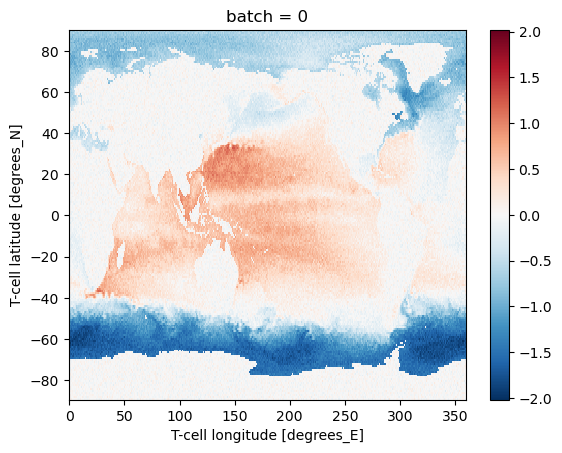

In [9]:
# plot them
x.isel(batch=0, channels=1).plot()
plt.show()

### Note that, although the above shows noisy inputs, this is not used in the actual training. The training and validation datasets are computed using the TSPackedDataset. The difference between the two is only the fact that the latter uses xarray_tensorstore instead of xarray/dask/zarr, which is relatively slower. Also the I did not implement the masking in noise in datasets.py. 
### Let's test the tensorstore version

In [10]:
# Get the training and validation datasets
training_data = TSPackedDataset(emulator, mode="training", meta_inputs=meta_sinputs, meta_targets=meta_xtargets)
validation_data = TSPackedDataset(emulator, mode="validation", meta_inputs=meta_sinputs, meta_targets=meta_xtargets)

In [11]:
# Get a sample input and target
x_ts, y_ts = training_data[0]

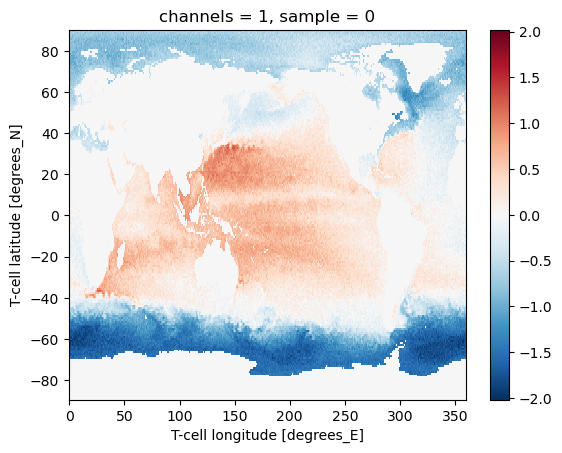

In [12]:
# Plot
x_ts.isel(channels=1).plot()
plt.show()

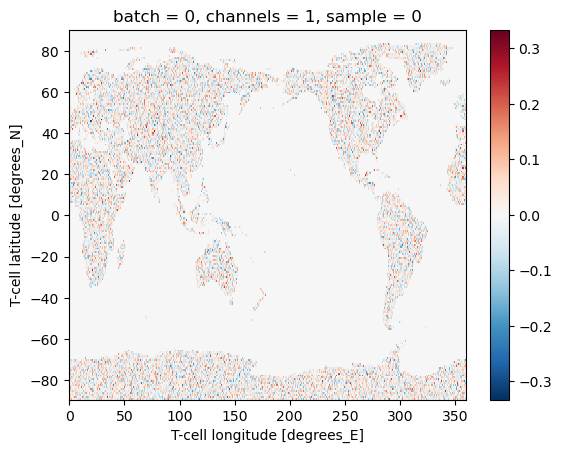

In [13]:
# plot the difference in x: this must show the non-masking in the former. 
x_diff = x.isel(batch=0, channels=1) - x_ts.isel(channels=1)
x_diff.plot()
plt.show()

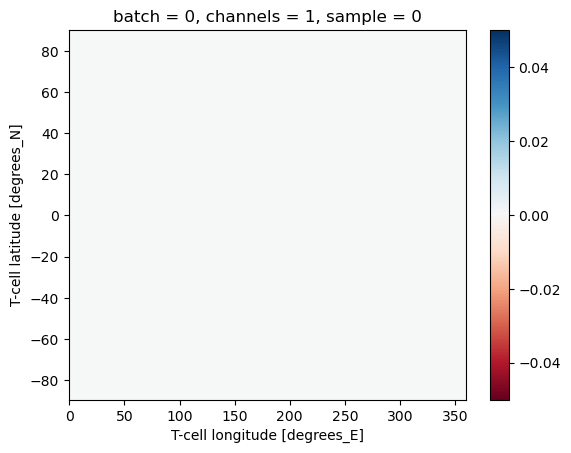

In [14]:
# Plot the difference in y: this should show near zero values everywhere coz
# no noise is added in targets anyway
y_diff = y.isel(batch=0, channels=1) - y_ts.isel(channels=1)
y_diff.plot(cmap="RdBu")
plt.show()